In [40]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split



In [41]:
df=pd.read_csv('weatherHistory.csv') 
# Display first 10 rows.
display(df.head(10))
# print(df.info())


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


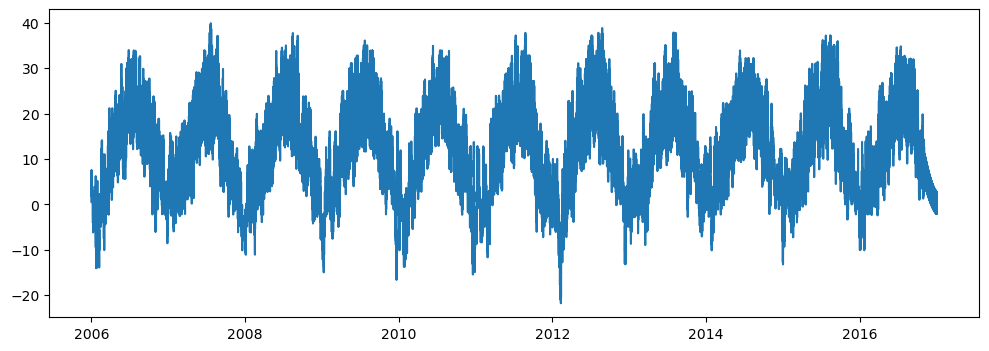

In [42]:
# Plot temperature trends over time.
df['Formatted Date']=pd.to_datetime(df['Formatted Date'],utc=True)
df=df.sort_values('Formatted Date')
features=['Temperature (C)','Humidity','Wind Speed (km/h)']
scaled=MinMaxScaler().fit_transform(df[features])
plt.figure(figsize=(12,4));plt.plot(df['Formatted Date'],df['Temperature (C)']);plt.show()

In [43]:
print("\nMissing Values:\n", df.isnull().sum())
df=df.dropna()
print("\nAfter removing Missing Values:")
print(df.isnull().sum())


Missing Values:
 Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

After removing Missing Values:
Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


In [44]:
# Define the features to use for the RNN model - we'll predict Temperature based on these three weather metrics
features=['Temperature (C)','Humidity','Wind Speed (km/h)']

# Initialize MinMaxScaler to normalize features to [0, 1] range
# This prevents features with larger scales from dominating the model training
scaler=MinMaxScaler()

# Fit and transform the selected features using the scaler
# scaled shape: (n_samples, 3) - each feature normalized between 0 and 1
scaled=scaler.fit_transform(df[features])

# Define sequence length: the RNN will use 7 days of historical data to predict the next day's temperature
seq_len=7

# Initialize empty lists to store sequences and targets
# X will contain input sequences (7 days of 3 features each)
# y will contain target values (temperature on the 8th day)
X,y=[],[]

# For each position i, extract 7 consecutive days as input (X)
# and use the temperature value from the 8th day as the target (y)
for i in range(len(scaled)-seq_len):
    X.append(scaled[i:i+seq_len])  # Extract 7-day window: shape (7, 3)
    y.append(scaled[i+seq_len,0])  # Extract temperature (column 0) of the next day

# Convert lists to numpy arrays for efficient computation
# X shape: (n_sequences, 7, 3) - 3D array for RNN input
# y shape: (n_sequences,) - 1D array of target temperatures
X=np.array(X); y=np.array(y)

# Split data into training and temporary sets (70% train, 30% test+validation)
# shuffle=False preserves temporal order - important for time series data
X_train,X_temp,y_train,y_temp=train_test_split(X,y,test_size=0.3,shuffle=False)

# Further split the temporary set into validation and test sets (50-50 split)
# This gives us 70% training, 15% validation, 15% test
X_val,X_test,y_val,y_test=train_test_split(X_temp,y_temp,test_size=0.5,shuffle=False)

# Print the shapes to verify the data splitting:
# X_train: sequences for training the model
# X_val: sequences for validation (tuning hyperparameters)
# X_test: sequences for final model evaluation
print(X_train.shape,X_val.shape,X_test.shape)

(67150, 7, 3) (14389, 7, 3) (14390, 7, 3)


## Part B: Model Development

In [45]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense,Dropout
# Build a SimpleRNN model
model=Sequential([
    SimpleRNN(64,input_shape=(X_train.shape[1],X_train.shape[2]),activation='tanh'),
])
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='linear'))
model.summary()
# Compile the model:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])


history=model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=50,batch_size=32)

2099/2099 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 5.7640e-04 - mae: 0.0176 - val_loss: 0.0024 - val_mae: 0.0454
Epoch 6/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 5.4132e-04 - mae: 0.0169 - val_loss: 0.0027 - val_mae: 0.0461
Epoch 7/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 5.2288e-04 - mae: 0.0166 - val_loss: 0.0025 - val_mae: 0.0459
Epoch 8/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 5.1261e-04 - mae: 0.0163 - val_loss: 0.0033 - val_mae: 0.0527
Epoch 9/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 5.0226e-04 - mae: 0.0162 - val_loss: 0.0024 - val_mae: 0.0441
Epoch 10/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 4.9585e-04 - mae: 0.0160 - val_loss: 0.0028 - val_mae: 0.0481
Epoch 11/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 4.8922e-04 - mae: 0.0158 - val_loss: 0.0031 - val_mae: 0.0502
Epoch 12/50
2099/2099 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 4.8530e-04 - mae: 0.0158 - val_loss: 0.0037 - val_mae: 0.0547
Epoch 13/50
209

In [ ]:
# Plot Training vs Validation Loss

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.show()

## Part C: Evaluation

In [47]:
# Predict temperature values for the test dataset
y_pred = model.predict(X_test)

# Create dummy arrays with the same number of features used by the scaler
n_features = scaler.n_features_in_
pred_dummy = np.zeros((len(y_pred), n_features))
actual_dummy = np.zeros((len(y_test), n_features))

# Store predicted and actual temperature in first column
pred_dummy[:, 0] = y_pred.flatten()
actual_dummy[:, 0] = y_test

# Convert back to original values
pred_temperature = scaler.inverse_transform(pred_dummy)[:, 0]
actual_temperature = scaler.inverse_transform(actual_dummy)[:, 0]

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

rmse = np.sqrt(mean_squared_error(actual_temperature, pred_temperature))
mae = mean_absolute_error(actual_temperature, pred_temperature)
r2 = r2_score(actual_temperature, pred_temperature)

print(f"RMSE : {rmse:.2f}")
print(f"MAE  : {mae:.2f}")
print(f"R² Score : {r2:.4f}")

450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
RMSE : 4.60
MAE  : 4.34
R² Score : 0.7536


In [ ]:

plt.figure(figsize=(14,6))

plt.plot(actual_temperature[:200],
         label='Actual Temperature',
         color='blue')

plt.plot(pred_temperature[:200],
         label='Predicted Temperature',
         color='red')

plt.title("Actual vs Predicted Temperature")

plt.xlabel("Test Samples")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(True)

plt.show()

In [50]:
# Forecast the Next 7 Days
last_sequence = scaled[-7:].copy()
forecast = []

current_sequence = last_sequence.copy()

for i in range(7):

    prediction = model.predict(
        current_sequence.reshape(1, 7, 3),
        verbose=0
    )

    forecast.append(prediction[0][0])

    next_day = current_sequence[-1].copy()

    # Replace temperature with predicted value
    next_day[0] = prediction[0][0]

    current_sequence = np.vstack(
        [current_sequence[1:], next_day]
    )
forecast_dummy = np.zeros((7, 3))

forecast_dummy[:,0] = forecast

forecast_temperature = scaler.inverse_transform(
    forecast_dummy
)[:,0]

print(forecast_temperature)

[ -2.9680874   -4.82085902  -6.44922324  -7.81803574  -8.90046734
  -9.63820541 -10.11647823]


In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    actual_temperature[-30:],
    label="Historical Temperature",
    color="blue"
)

future_index = range(30, 37)

plt.plot(
    future_index,
    forecast_temperature,
    marker='o',
    linestyle='--',
    color='red',
    label="Next 7-Day Forecast"
)

plt.title("Next 7 Days Temperature Forecast")

plt.xlabel("Days")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(True)

plt.show()